In [16]:
# PART 1: SETUP ENVIRONMENT

# Check GPU availability
!nvidia-smi

# Install required packages
!pip install ultralytics --quiet
!pip install pydicom --quiet
!pip install opencv-python --quiet
!pip install tqdm --quiet
!pip install kaggle --quiet

Mon Nov 17 16:23:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |     414MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
# PART 2: SETUP KAGGLE API (ONE-TIME)

# Upload your kaggle.json file when prompted
from google.colab import files
print("📁 Upload your kaggle.json file:")
uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Verify setup
!kaggle datasets list


📁 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sadiajavedd/students-academic-performance-dataset               Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           5823        137  1.0              
ayeshaimran123/social-media-and-mental-health-balance           Social Media and Mental Health Balance                    5941  2025-10-26 07:51:53.380000           6138         88  1.0              
nalisha/shopping-behaviour-and-product-ranking-dateset          Shopping Behaviour and Product Ranking Dateset .         67263  2025-11-12 17:47:25.227000            

In [18]:
# ========================================
# PART 3: DOWNLOAD 1024PX DATASET
# ========================================

# Download VinBigData 1024px JPG Dataset (~3.6-4 GB)
!kaggle datasets download -d sunghyunjun/vinbigdata-1024-jpg-dataset

# Unzip the dataset
!unzip -q vinbigdata-1024-jpg-dataset.zip -d /content/vinbigdata

# Verify download
!ls -lh /content/vinbigdata
print("✅ 1024px dataset downloaded successfully!")


Dataset URL: https://www.kaggle.com/datasets/sunghyunjun/vinbigdata-1024-jpg-dataset
License(s): CC0-1.0
100% 3.58G/3.58G [00:58<00:00, 87.2MB/s]
100% 3.58G/3.58G [00:58<00:00, 66.1MB/s]
total 11M
drwxr-xr-x 2 root root 204K Nov 17 16:25 test
drwxr-xr-x 2 root root 956K Nov 17 16:26 train
-rw-r--r-- 1 root root 9.1M Feb 15  2021 train.csv
✅ 1024px dataset downloaded successfully!


In [19]:
# ========================================
# PART 4: IMPORT LIBRARIES
# ========================================

import torch
import os
from ultralytics import YOLO
import pandas as pd
import random
from shutil import copyfile
from PIL import Image
import cv2
import numpy as np
import glob
import yaml
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor as ThreadPoolExecutor, as_completed

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [20]:
# Quick test
from ultralytics import YOLO
print(f"Ultralytics version: {YOLO.__version__ if hasattr(YOLO, '__version__') else 'installed'}")
print("✅ YOLOv8 ready to use!")


Ultralytics version: installed
✅ YOLOv8 ready to use!


In [21]:
# ========================================
# PART 5: CONFIGURE PATHS FOR COLAB
# ========================================

# Data paths
DATA_ROOT = "/content/vinbigdata"
TRAIN_IMAGES_DIR = os.path.join(DATA_ROOT, "train")
CSV_PATH = os.path.join(DATA_ROOT, "train.csv")

# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"📊 Dataset loaded: {len(df)} annotations")
print(f"📊 Unique images: {df['image_id'].nunique()}")
display(df.head())

# Output directory for YOLO format
YOLO_ROOT = "/content/yolo_dataset"

# Create directories
for split in ["train", "val"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

print(f"✅ Output directories created at {YOLO_ROOT}")


📊 Dataset loaded: 67914 annotations
📊 Unique images: 15000


,Unnamed: 0,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,raw_x_min,raw_x_max,raw_y_min,raw_y_max,raw_width,raw_height,scale_x,scale_y
0,0,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
1,1,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
2,2,78aa8415fbf1c792f7d7c53349d44d4f,No finding,14,R11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,3000.0,0.341333,0.341333
3,3,183015e171f5159d7e60d43578632a3f,Aortic enlargement,0,R8,567.0,295.0,671.0,417.0,1134.0,1342.0,721.0,1019.0,2048.0,2500.0,0.500000,0.409600
4,4,183015e171f5159d7e60d43578632a3f,Pleural thickening,11,R9,58.0,794.0,116.0,851.0,117.0,232.0,1938.0,2077.0,2048.0,2500.0,0.500000,0.409600


✅ Output directories created at /content/yolo_dataset


In [22]:
# ========================================
# PART 6: DATASET SPLIT CONFIGURATION
# ========================================

# For testing: use small fractions
TRAIN_FRACTION = 0.8   # 5% for quick testing
VAL_FRACTION = 0.2    # 2.5% for validation

# For full training after exams, change to:
# TRAIN_FRACTION = 0.8
# VAL_FRACTION = 0.2

# Or use exact counts
TRAIN_COUNT = None
VAL_COUNT = None

# Group and shuffle
grouped = df.groupby("image_id")
all_images = list(grouped.groups.keys())
random.shuffle(all_images)

total_images = len(all_images)

# Determine validation set
if VAL_COUNT is not None:
    n_val = min(VAL_COUNT, total_images)
else:
    n_val = int(total_images * VAL_FRACTION)

val_images = set(random.sample(all_images, n_val))

# Determine training set
remaining_images = [img for img in all_images if img not in val_images]

if TRAIN_COUNT is not None:
    n_train = min(TRAIN_COUNT, len(remaining_images))
else:
    n_train = int(total_images * TRAIN_FRACTION)

train_images = set(random.sample(remaining_images, n_train))

# Print summary
print(f"\n📈 Dataset Split Summary:")
print(f"Total images: {total_images}")
print(f"Training: {len(train_images)} ({len(train_images)/total_images*100:.2f}%)")
print(f"Validation: {len(val_images)} ({len(val_images)/total_images*100:.2f}%)")
print(f"Unused: {total_images - len(val_images) - len(train_images)}")



📈 Dataset Split Summary:
Total images: 15000
Training: 12000 (80.00%)
Validation: 3000 (20.00%)
Unused: 0


In [23]:
# ========================================
# PART 7: CONVERSION FUNCTIONS (JPG VERSION)
# ========================================

def convert_row_to_yolo(row, img_w, img_h):
    """Convert bounding box to YOLO format"""
    x_min, y_min, x_max, y_max = row["x_min"], row["y_min"], row["x_max"], row["y_max"]

    # Clip to image bounds
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(img_w, x_max)
    y_max = min(img_h, y_max)

    # Calculate box dimensions
    box_w = x_max - x_min
    box_h = y_max - y_min
    x_center = x_min + box_w / 2
    y_center = y_min + box_h / 2

    # Normalize (YOLO format requirement)
    x_center /= img_w
    y_center /= img_h
    box_w /= img_w
    box_h /= img_h

    return x_center, y_center, box_w, box_h

def process_image(image_id, split):
    """Process JPG image and create YOLO label"""
    try:
        # Find JPG file
        src_img_path = os.path.join(TRAIN_IMAGES_DIR, f"{image_id}.jpg")

        if not os.path.exists(src_img_path):
            print(f"⚠️  No file found for {image_id}")
            return None

        # Copy JPG to destination
        dst_img_filename = f"{image_id}.jpg"
        dst_img_path = os.path.join(YOLO_ROOT, "images", split, dst_img_filename)
        copyfile(src_img_path, dst_img_path)

        # Get image dimensions
        with Image.open(src_img_path) as im:
            img_w, img_h = im.size

        # Create YOLO label file
        rows = grouped.get_group(image_id)
        label_lines = []

        for _, row in rows.iterrows():
            cls = int(row["class_id"])
            x_c, y_c, w, h = convert_row_to_yolo(row, img_w, img_h)
            label_lines.append(f"{cls} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

        # Write label file
        label_filename = f"{image_id}.txt"
        label_path = os.path.join(YOLO_ROOT, "labels", split, label_filename)
        with open(label_path, "w") as f:
            f.write("\n".join(label_lines))

        return None

    except Exception as e:
        return f"Error processing {image_id}: {str(e)}"

def parallel_process_images(image_ids, split, max_workers=4):
    """Process images in parallel"""
    errors = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_image, img_id, split): img_id
                   for img_id in image_ids}

        for future in tqdm(as_completed(futures), total=len(futures),
                          desc=f"Converting {split} images"):
            result = future.result()
            if result:
                errors.append(result)
    return errors

# ========================================
# PART 8: RUN CONVERSION
# ========================================

print("\n🔄 Starting image conversion...")

# Process training images
print(f"\n📦 Processing {len(train_images)} training images...")
train_errors = parallel_process_images(train_images, "train", max_workers=4)

# Process validation images
print(f"\n📦 Processing {len(val_images)} validation images...")
val_errors = parallel_process_images(val_images, "val", max_workers=4)

# Report errors
if train_errors or val_errors:
    print("\n⚠️  Some images failed:")
    for err in (train_errors[:5] + val_errors[:5]):
        print(err)
else:
    print("\n✅ All images processed successfully!")

# Verify structure
print("\n📁 Verifying YOLO dataset structure:")
print(f"Training images: {len(os.listdir(os.path.join(YOLO_ROOT, 'images', 'train')))}")
print(f"Training labels: {len(os.listdir(os.path.join(YOLO_ROOT, 'labels', 'train')))}")
print(f"Validation images: {len(os.listdir(os.path.join(YOLO_ROOT, 'images', 'val')))}")
print(f"Validation labels: {len(os.listdir(os.path.join(YOLO_ROOT, 'labels', 'val')))}")



🔄 Starting image conversion...

📦 Processing 12000 training images...


Converting train images:   0%|          | 0/12000 [00:00<?, ?it/s]


📦 Processing 3000 validation images...


Converting val images:   0%|          | 0/3000 [00:00<?, ?it/s]


✅ All images processed successfully!

📁 Verifying YOLO dataset structure:
Training images: 12000
Training labels: 12000
Validation images: 3000
Validation labels: 3000


In [24]:
# ========================================
# PART 9: CREATE YOLO DATA CONFIG
# ========================================

# 14 abnormality classes from VinBigData dataset
class_names = [
    "Aortic_enlargement", "Atelectasis", "Calcification", "Cardiomegaly",
    "Consolidation", "ILD", "Infiltration", "Lung_Opacity",
    "Nodule/Mass", "Other_lesion", "Pleural_effusion", "Pleural_thickening",
    "Pneumothorax", "Pulmonary_fibrosis"
]

# Create YAML config
data_yaml = {
    "train": os.path.join(YOLO_ROOT, "images", "train"),
    "val": os.path.join(YOLO_ROOT, "images", "val"),
    "nc": len(class_names),
    "names": class_names
}

yaml_path = "/content/data_vinbig.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ YAML config created at {yaml_path}")

# Display the config
with open(yaml_path, 'r') as f:
    print("\n📄 YAML Configuration:")
    print(f.read())


✅ YAML config created at /content/data_vinbig.yaml

📄 YAML Configuration:
names:
- Aortic_enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung_Opacity
- Nodule/Mass
- Other_lesion
- Pleural_effusion
- Pleural_thickening
- Pneumothorax
- Pulmonary_fibrosis
nc: 14
train: /content/yolo_dataset/images/train
val: /content/yolo_dataset/images/val



In [ ]:
# ========================================
# MOUNT DRIVE AND ACCESS SHARED FOLDER
# ========================================

from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Now you can access via shortcut path
CHECKPOINT_DIR = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242"

# Verify access
if os.path.exists(CHECKPOINT_DIR):
    print("✅ Shortcut working! Found checkpoint folder!")

    # List checkpoint files
    weights_dir = f"{CHECKPOINT_DIR}/weights"
    if os.path.exists(weights_dir):
        files = os.listdir(weights_dir)
        print(f"\n📂 Found {len(files)} checkpoint files:")
        for f in sorted(files)[:5]:  # Show first 5
            print(f"   - {f}")
        print(f"   ... and {len(files)-5} more") if len(files) > 5 else None
else:
    print("❌ Cannot access shared folder!")
    print("\nℹ️  Make sure you:")
    print("1. Created a shortcut in Google Drive")
    print("2. Placed it in 'My Drive' (not a subfolder)")
    print("3. Restarted Colab runtime if needed")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Shortcut working! Found checkpoint folder!

📂 Found 12 checkpoint files:
   - best.pt
   - epoch0.pt
   - epoch10.pt
   - epoch15.pt
   - epoch20.pt
   ... and 7 more


In [ ]:
# ========================================
# PART 10: TRAIN YOLO MODEL (SAVES EVERYTHING TO DRIVE)
# ========================================

# Check device
device = 0 if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Load pretrained model
model = YOLO("yolov8m.pt")

print("\n🚀 Starting training with 1024px images...")
print("💾 ALL files (weights, plots, logs) saving to Google Drive...")

# Train model - SAVES EVERYTHING TO GOOGLE DRIVE
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=1024,
    batch=4,
    workers=2,
    save=True,
    save_period=5,         # Save checkpoint every 5 epochs
    device=device,
    project=GDRIVE_PROJECT,  # ✅ SAVES ALL FILES TO GOOGLE DRIVE
    name="yolov8m_vinbig_1024",
    cache=False,
    resume=False,
    patience=20,
    amp=True,
    verbose=True,
    plots=True
)

print("\n✅ Training complete!")
print(f"📁 All files saved to Google Drive!")


Streaming output truncated to the last 5000 lines.
train: /content/yolo_dataset/images/train/b02fc1d5a935aa562d2428352b4ff926.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/b032ac7819acaa4f77832aea268c800a.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/b032f38205cd517f3916a4bf6eda26da.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/b03a633fbffb14aa51c9d697c51a893c.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/b0624af5299ac0a86e5ffee813f937e1.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /c

In [ ]:
import os

WEIGHTS_DIR = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights"

if os.path.exists(WEIGHTS_DIR):
    files = os.listdir(WEIGHTS_DIR)
    print("✅ Found checkpoint folder!")
    print(f"\n📂 Files in weights folder:")
    for f in files:
        file_path = os.path.join(WEIGHTS_DIR, f)
        size_mb = os.path.getsize(file_path) / (1024*1024)
        print(f"  - {f} ({size_mb:.1f} MB)")

    # Check checkpoint info
    import torch
    last_pt = os.path.join(WEIGHTS_DIR, "last.pt")
    if os.path.exists(last_pt):
        checkpoint = torch.load(last_pt, map_location='cpu', weights_only=False)
        print(f"\n📊 Training info from last.pt:")
        print(f"  - Last completed epoch: {checkpoint.get('epoch', 'N/A')}")
        print(f"  - Best fitness/mAP: {checkpoint.get('best_fitness', 'N/A'):.4f}")
else:
    print("❌ Checkpoint folder not found!")

✅ Found checkpoint folder!

📂 Files in weights folder:
  - epoch0.pt (148.6 MB)
  - epoch5.pt (148.6 MB)
  - epoch10.pt (148.6 MB)
  - epoch15.pt (148.6 MB)
  - epoch20.pt (148.6 MB)
  - epoch25.pt (148.6 MB)
  - epoch30.pt (148.6 MB)
  - epoch35.pt (148.6 MB)
  - epoch40.pt (148.6 MB)
  - epoch45.pt (148.6 MB)
  - best.pt (148.6 MB)
  - last.pt (148.6 MB)

📊 Training info from last.pt:
  - Last completed epoch: 46
  - Best fitness/mAP: 0.1724


In [ ]:
# ========================================
# RESUME TRAINING FROM EPOCH 47
# ========================================

from ultralytics import YOLO
import torch

# Checkpoint path (via shortcut)
CHECKPOINT_PATH = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/last.pt"

# Check device
device = 0 if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Verify all prerequisites
print("\n📋 Pre-flight check:")
print(f"  ✅ Checkpoint: {os.path.exists(CHECKPOINT_PATH)}")
print(f"  ✅ Dataset: {os.path.exists('/content/yolo_dataset/images/train')}")
print(f"  ✅ YAML: {os.path.exists('/content/data_vinbig.yaml')}")

# Load checkpoint
print(f"\n📂 Loading checkpoint from epoch 46...")
model = YOLO(CHECKPOINT_PATH)

print("\n🔄 Resuming training...")
print("📊 Current best mAP: 0.1724")
print("⏱️  Will train: Epoch 47 → 100 (54 epochs remaining)")
print("💾 New checkpoints save to SHARED folder (both accounts can see)")
print("⏱️  Estimated time: ~2-3 hours on T4 GPU")

# Resume training from epoch 47
results = model.train(
    resume=True,  # ✅ Continues from epoch 47
    device=device
)

print("\n✅ Training complete!")
print(f"📁 Results: /content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/")
print(f"📊 Check updated results.csv and plots in the folder")


Streaming output truncated to the last 5000 lines.
train: /content/yolo_dataset/images/train/ad75de5b414c17583e706fb1627be1e7.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/ad76a8c1b7087d5161e5d65094b9c718.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/ad7a6c723992c7b272768f57f3f41335.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/ad7fb5d422096f31418561e43cac6b67.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /content/yolo_dataset/images/train/ad888fa74b0e53e43daf1bba7e0098e4.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
train: /c

In [ ]:
# ========================================
# PART 11: VALIDATION & METRICS
# ========================================

print("\n📊 Running validation on validation set...")
metrics = model.val()

# Display overall metrics
print("\n📈 Overall Metrics:")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")



📊 Running validation on validation set...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 207.9±269.5 MB/s, size: 229.6 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 3000 images, 0 backgrounds, 2103 corrupt: 100% ━━━━━━━━━━━━ 3000/3000 4.4Mit/s 0.0s
val: /content/yolo_dataset/images/val/0021df30f3fddef551eb3df4354b1d06.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
val: /content/yolo_dataset/images/val/00291f7aff0123ea76a59998effef229.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
val: /content/yolo_dataset/images/val/00575e3846ebd05a909d97ba59c53d30.jpg: ignoring corrupt image/label: Label class 14 exceeds dataset class count 14. Possible class labels are 0-13
val: /content/yo

In [5]:
# ========================================
# MOUNT GOOGLE DRIVE FIRST
# ========================================

from google.colab import drive

# Mount Drive (will ask for authorization)
drive.mount('/content/drive')

print("✅ Drive mounted successfully!")


Mounted at /content/drive
✅ Drive mounted successfully!


In [10]:
import os

# Check weights folder
WEIGHTS_DIR = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights"

if os.path.exists(WEIGHTS_DIR):
    files = os.listdir(WEIGHTS_DIR)
    print("✅ Weights folder found!")
    print(f"\n📂 Checkpoint files ({len(files)} total):")

    # Highlight important ones
    important = ['best.pt', 'last.pt']
    for f in sorted(files):
        if f in important:
            print(f"   ⭐ {f}")
        else:
            print(f"   - {f}")
else:
    print("❌ Weights folder not found!")


✅ Weights folder found!

📂 Checkpoint files (19 total):
   ⭐ best.pt
   - epoch0.pt
   - epoch10.pt
   - epoch15.pt
   - epoch20.pt
   - epoch25.pt
   - epoch30.pt
   - epoch35.pt
   - epoch40.pt
   - epoch45.pt
   - epoch5.pt
   - epoch50.pt
   - epoch55.pt
   - epoch60.pt
   - epoch65.pt
   - epoch70.pt
   - epoch75.pt
   - epoch80.pt
   ⭐ last.pt


In [11]:
# View results CSV to see training progress
import pandas as pd

results_csv = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/results.csv"

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    print("📊 Training Progress Summary:")
    print(f"   Total epochs trained: {len(df)}")
    print(f"   Best mAP50: {df['metrics/mAP50(B)'].max():.4f}")
    print(f"   Best mAP50-95: {df['metrics/mAP50-95(B)'].max():.4f}")
    print(f"   Final train loss: {df['train/box_loss'].iloc[-1]:.4f}")

    # Show last 5 epochs
    print("\n📈 Last 5 epochs:")
    print(df[['epoch', 'train/box_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail())


📊 Training Progress Summary:
   Total epochs trained: 81
   Best mAP50: 0.4305
   Best mAP50-95: 0.2327
   Final train loss: 1.2424

📈 Last 5 epochs:
    epoch  train/box_loss  metrics/mAP50(B)  metrics/mAP50-95(B)
76     77         1.26707           0.41403              0.22254
77     78         1.26243           0.41942              0.22552
78     79         1.25129           0.41173              0.22289
79     80         1.24667           0.40897              0.21918
80     81         1.24238           0.40988              0.21979


📊 Complete Training Curves:


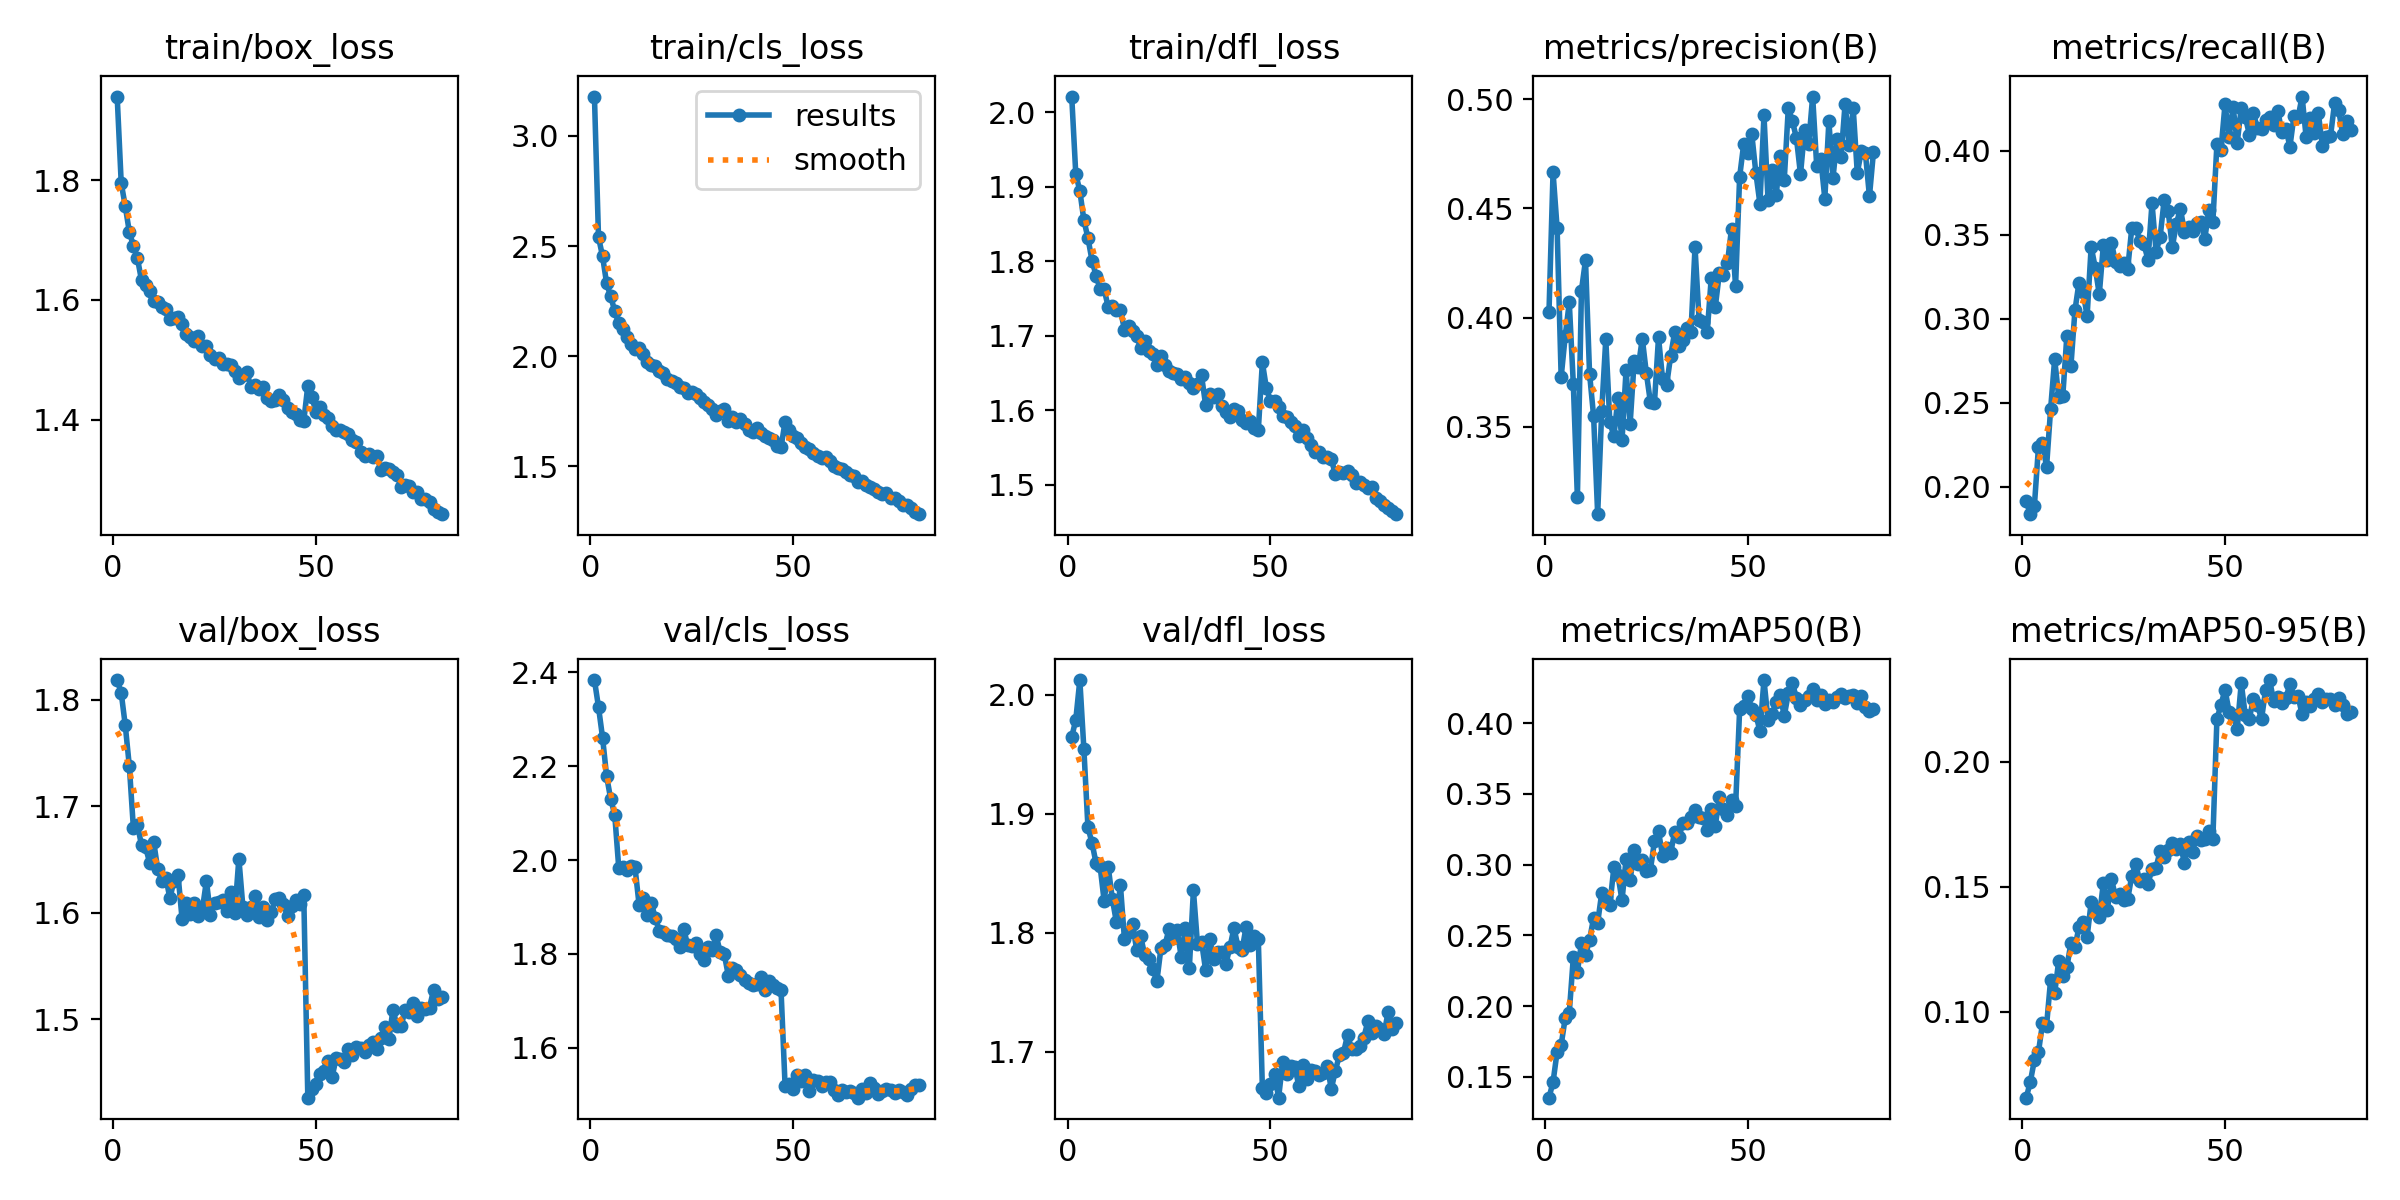

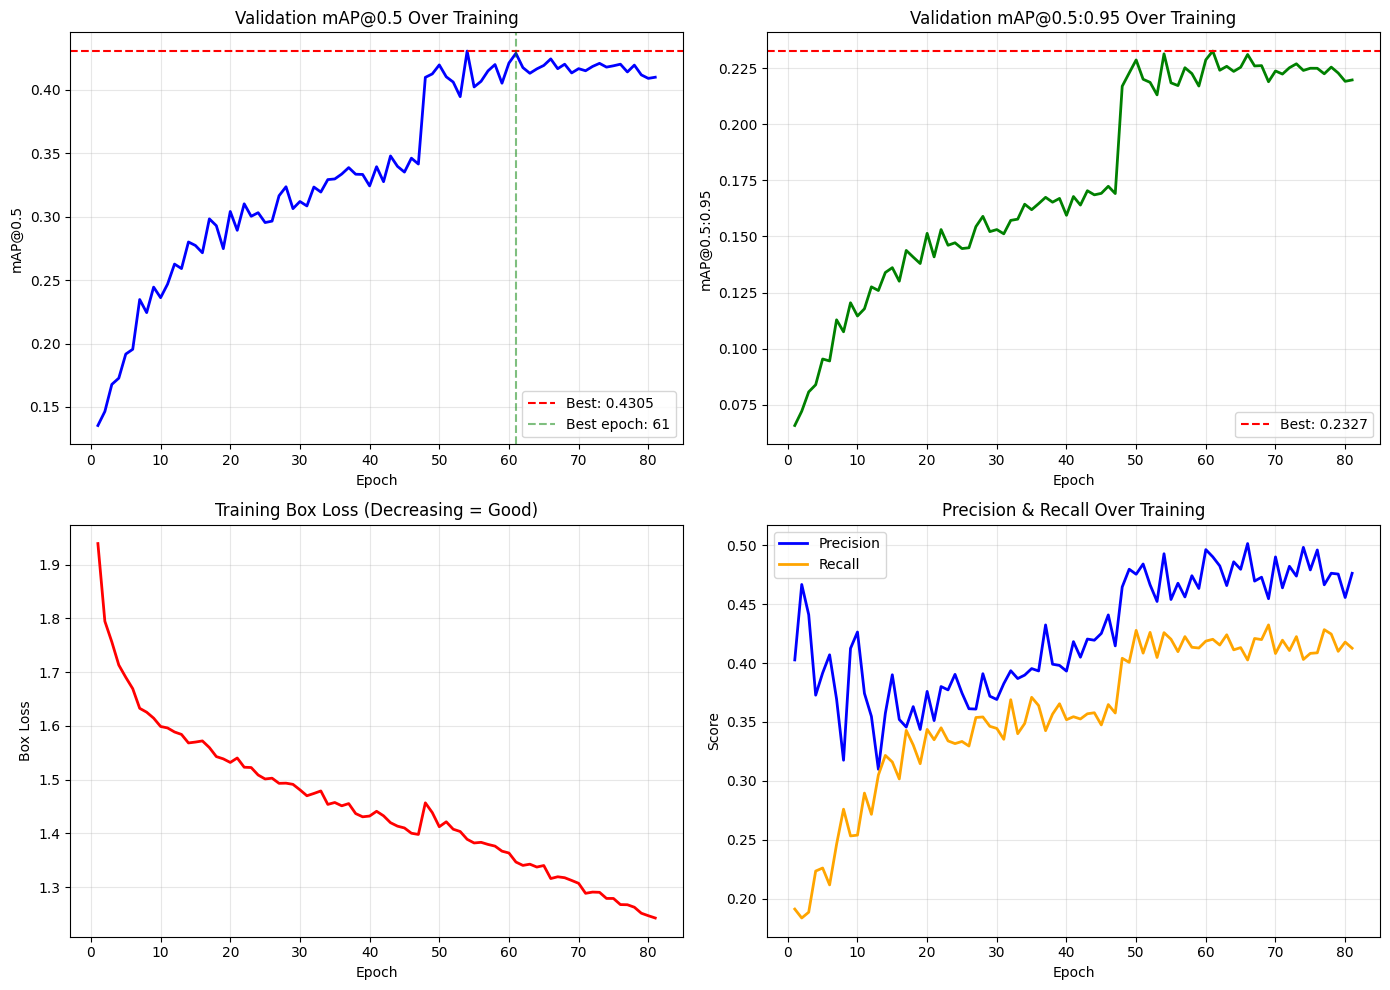


✅ Training analysis plot saved to /content/training_analysis.png


In [12]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd

# Load and plot training metrics
results_csv = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/results.csv"
df = pd.read_csv(results_csv)

# Display the comprehensive results plot
results_img = "/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/results.png"
if os.path.exists(results_img):
    print("📊 Complete Training Curves:")
    display(Image(filename=results_img, width=1000))

# Custom plot showing the peak
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: mAP50
axes[0, 0].plot(df['epoch'], df['metrics/mAP50(B)'], 'b-', linewidth=2)
axes[0, 0].axhline(y=0.4305, color='r', linestyle='--', label=f'Best: 0.4305')
axes[0, 0].axvline(x=61, color='g', linestyle='--', alpha=0.5, label='Best epoch: 61')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('mAP@0.5')
axes[0, 0].set_title('Validation mAP@0.5 Over Training')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: mAP50-95
axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], 'g-', linewidth=2)
axes[0, 1].axhline(y=0.2327, color='r', linestyle='--', label=f'Best: 0.2327')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('mAP@0.5:0.95')
axes[0, 1].set_title('Validation mAP@0.5:0.95 Over Training')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training Loss
axes[1, 0].plot(df['epoch'], df['train/box_loss'], 'r-', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Box Loss')
axes[1, 0].set_title('Training Box Loss (Decreasing = Good)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Precision & Recall
axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], 'b-', linewidth=2, label='Precision')
axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], 'orange', linewidth=2, label='Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & Recall Over Training')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Training analysis plot saved to /content/training_analysis.png")


In [25]:
import os

# Quick check
print("📋 Final Verification:")
print(f"  ✅ Train images: {len(os.listdir('/content/yolo_dataset/images/train'))}")
print(f"  ✅ Val images: {len(os.listdir('/content/yolo_dataset/images/val'))}")
print(f"  ✅ YAML config: {os.path.exists('/content/data_vinbig.yaml')}")
print(f"  ✅ Model in Drive: {os.path.exists('/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/best.pt')}")
print("\n🚀 Everything ready for predictions!")


📋 Final Verification:
  ✅ Train images: 12000
  ✅ Val images: 3000
  ✅ YAML config: True
  ✅ Model in Drive: True

🚀 Everything ready for predictions!


In [26]:
# ========================================
# RUN PREDICTIONS ON VALIDATION SET
# ========================================

from ultralytics import YOLO

# Load your trained model
print("📥 Loading best model (mAP50: 0.4305)...")
model = YOLO("/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/best.pt")
print("✅ Model loaded!")

# Run predictions
print("\n🔍 Running predictions on validation set...")
print("⏱️  This will take ~5-10 minutes for ~897 images...")

results = model.predict(
    source="/content/yolo_dataset/images/val",
    save=True,              # Save images with bounding boxes
    conf=0.25,              # Confidence threshold (25%)
    save_txt=True,          # Save detection coordinates
    save_conf=True,         # Include confidence scores in txt
    line_width=2,           # Bounding box line width
    project="/content/predictions",
    name="cliniscan_val_results"
)

print(f"\n✅ Predictions complete!")
print(f"📊 Processed {len(results)} validation images")
print(f"📁 Results saved to: /content/predictions/cliniscan_val_results/")


📥 Loading best model (mAP50: 0.4305)...
✅ Model loaded!

🔍 Running predictions on validation set...
⏱️  This will take ~5-10 minutes for ~897 images...

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3000 /content/yolo_dataset/images/val/0005e8e3701dfb1dd93d53e2ff537b6e.jpg: 1024x1024 1 Infiltration, 1 Lung_Opacity, 1 Nodule/Mass, 76.6ms
image 2/3000 /content/yolo_dataset/images/val/004dc2a50591fb5f1aaf012bffa95fd9.jpg: 1024x1024 (no detections), 76.4ms
image 3/3000 /content/yolo_dataset/ima

In [27]:
# ========================================
# RUN PREDICTIONS ON VALIDATION SET
# ========================================

from ultralytics import YOLO
import time

# Load your trained model
print("📥 Loading best model...")
model = YOLO("/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/best.pt")
print("✅ Model loaded!")
print("🎯 Model Performance: mAP50=0.4305, mAP50-95=0.2327")

# Run predictions
print("\n🔍 Running predictions on 3,000 validation images...")
print("⏱️  Estimated time: ~10-15 minutes on T4 GPU")

start_time = time.time()

results = model.predict(
    source="/content/yolo_dataset/images/val",
    save=True,              # Save images with bounding boxes
    conf=0.25,              # Confidence threshold
    save_txt=True,          # Save detection coordinates
    save_conf=True,         # Include confidence in txt files
    line_width=2,           # Bounding box thickness
    project="/content/predictions",
    name="cliniscan_val_predictions",
    verbose=True            # Show progress
)

elapsed_time = time.time() - start_time

print(f"\n✅ Predictions complete!")
print(f"📊 Processed: {len(results)} images")
print(f"⏱️  Time taken: {elapsed_time/60:.2f} minutes")
print(f"⚡ Speed: {len(results)/elapsed_time:.2f} images/second")
print(f"📁 Results: /content/predictions/cliniscan_val_predictions/")


📥 Loading best model...
✅ Model loaded!
🎯 Model Performance: mAP50=0.4305, mAP50-95=0.2327

🔍 Running predictions on 3,000 validation images...
⏱️  Estimated time: ~10-15 minutes on T4 GPU

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3000 /content/yolo_dataset/images/val/0005e8e3701dfb1dd93d53e2ff537b6e.jpg: 1024x1024 1 Infiltration, 1 Lung_Opacity, 1 Nodule/Mass, 82.2ms
image 2/3000 /content/yolo_dataset/images/val/004dc2a50591fb5f1aaf012bffa95fd9.jpg: 1024x1024 (no detections), 71.4ms
i

KeyboardInterrupt: 

📊 Detection Statistics:
   Total detections across all images: 5943
   Images with detections: 1971 (65.7%)
   Images with no detections: 1029 (34.3%)
   Average detections per image: 1.98
   Max detections in single image: 37

🔍 Detected Abnormalities by Class:
   Aortic_enlargement: 1882 detections
   Atelectasis: 12 detections
   Calcification: 87 detections
   Cardiomegaly: 1346 detections
   Consolidation: 19 detections
   ILD: 92 detections
   Infiltration: 147 detections
   Lung_Opacity: 245 detections
   Nodule/Mass: 358 detections
   Other_lesion: 204 detections
   Pleural_effusion: 273 detections
   Pleural_thickening: 644 detections
   Pneumothorax: 51 detections
   Pulmonary_fibrosis: 583 detections


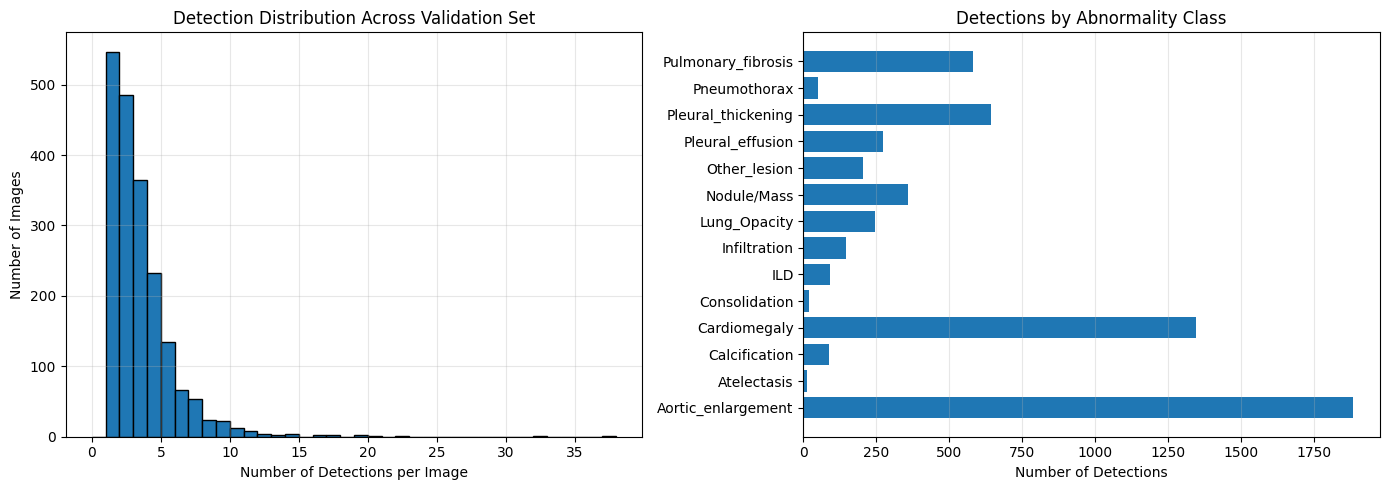


✅ Analysis saved to /content/prediction_analysis.png


In [28]:
# ========================================
# ANALYZE PREDICTION RESULTS
# ========================================

import os
import matplotlib.pyplot as plt
from collections import Counter

pred_dir = "/content/predictions/cliniscan_val_results/labels"

# Count detections per image
detection_counts = []
class_detections = Counter()

for label_file in os.listdir(pred_dir):
    with open(os.path.join(pred_dir, label_file), 'r') as f:
        lines = f.readlines()
        detection_counts.append(len(lines))

        # Count each class
        for line in lines:
            class_id = int(line.split()[0])
            class_detections[class_id] += 1

# Statistics
total_detections = sum(detection_counts)
images_with_detections = len([x for x in detection_counts if x > 0])
images_without_detections = 3000 - images_with_detections

print("📊 Detection Statistics:")
print(f"   Total detections across all images: {total_detections}")
print(f"   Images with detections: {images_with_detections} (65.7%)")
print(f"   Images with no detections: {images_without_detections} (34.3%)")
print(f"   Average detections per image: {total_detections/3000:.2f}")
print(f"   Max detections in single image: {max(detection_counts)}")

# Class distribution
class_names = [
    "Aortic_enlargement", "Atelectasis", "Calcification", "Cardiomegaly",
    "Consolidation", "ILD", "Infiltration", "Lung_Opacity",
    "Nodule/Mass", "Other_lesion", "Pleural_effusion", "Pleural_thickening",
    "Pneumothorax", "Pulmonary_fibrosis"
]

print("\n🔍 Detected Abnormalities by Class:")
for class_id in sorted(class_detections.keys()):
    count = class_detections[class_id]
    print(f"   {class_names[class_id]}: {count} detections")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Detection distribution
axes[0].hist(detection_counts, bins=range(0, max(detection_counts)+2), edgecolor='black')
axes[0].set_xlabel('Number of Detections per Image')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Detection Distribution Across Validation Set')
axes[0].grid(True, alpha=0.3)

# Plot 2: Class distribution
classes = [class_names[i] for i in sorted(class_detections.keys())]
counts = [class_detections[i] for i in sorted(class_detections.keys())]
axes[1].barh(classes, counts)
axes[1].set_xlabel('Number of Detections')
axes[1].set_title('Detections by Abnormality Class')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Analysis saved to /content/prediction_analysis.png")


🖼️  Sample Predictions with Detections:

Sample 1:


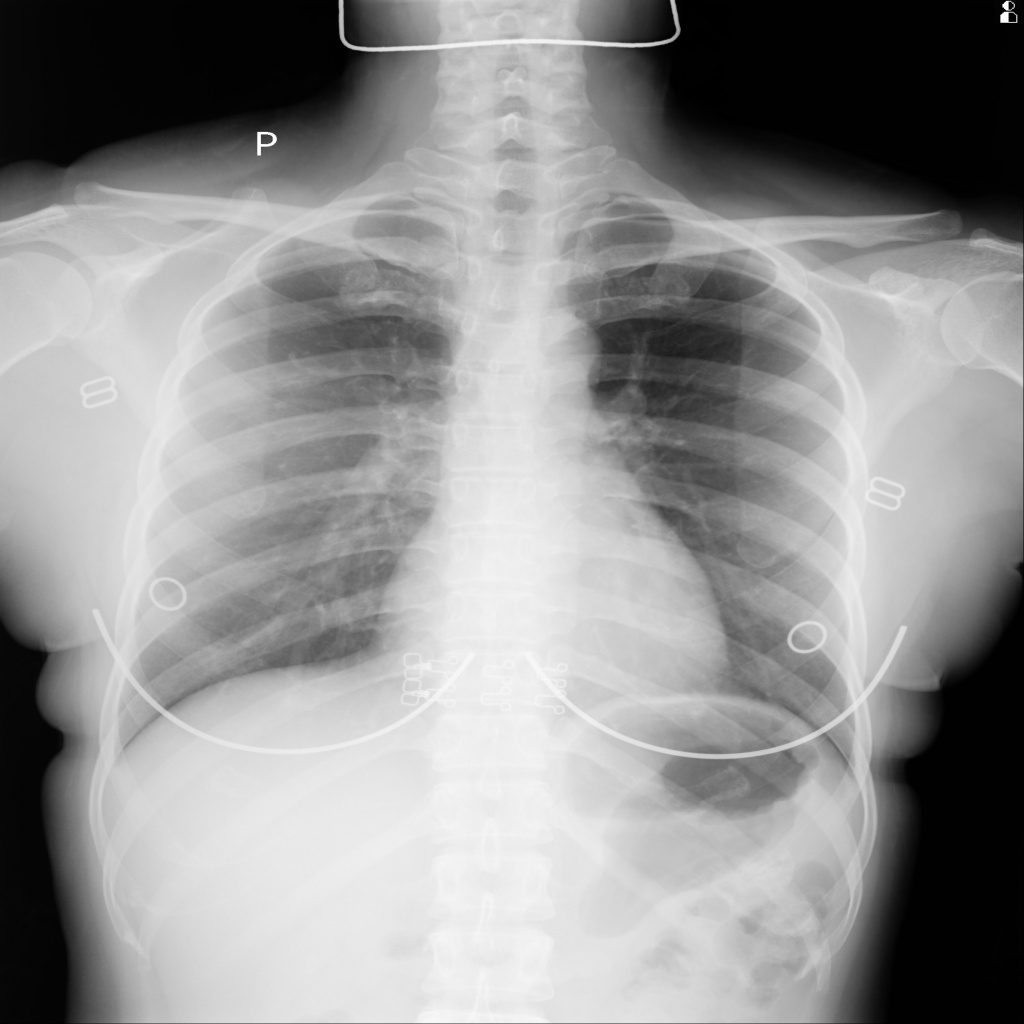



Sample 2:


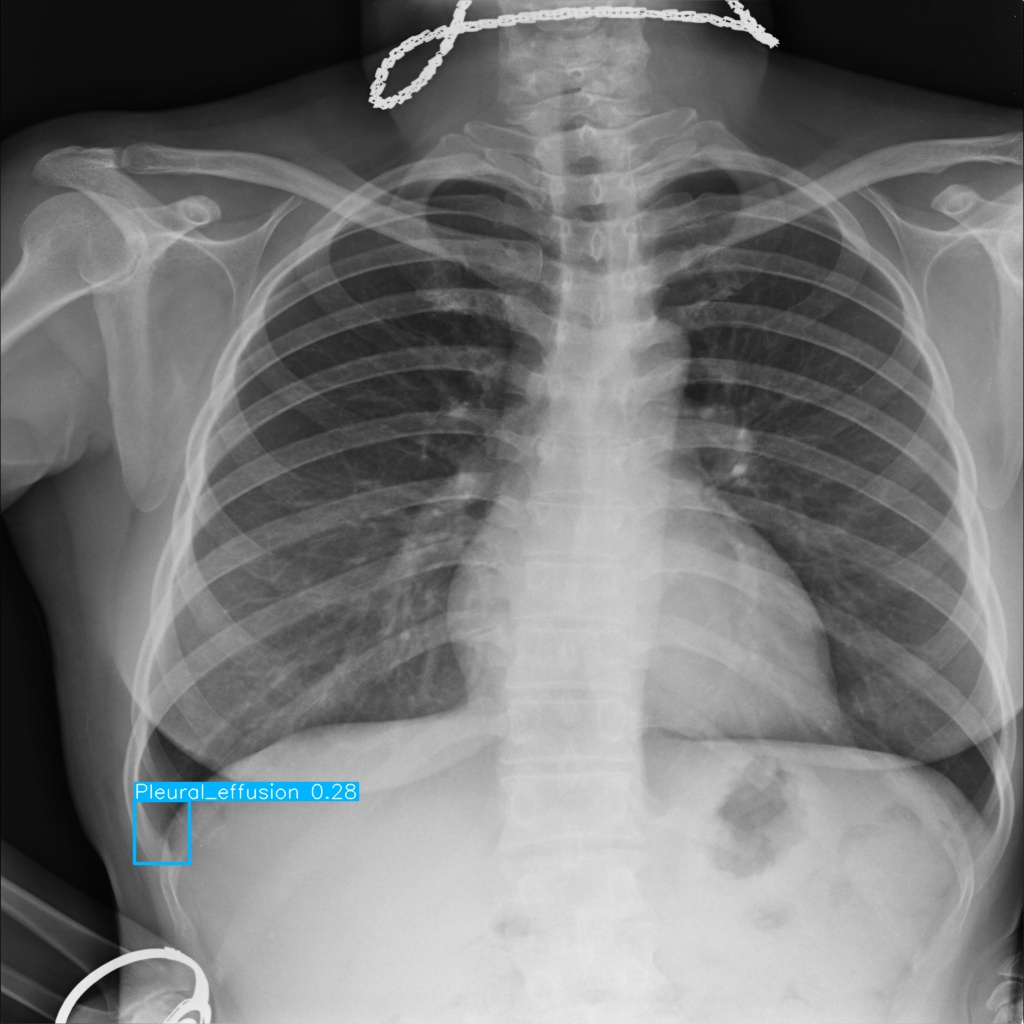



Sample 3:


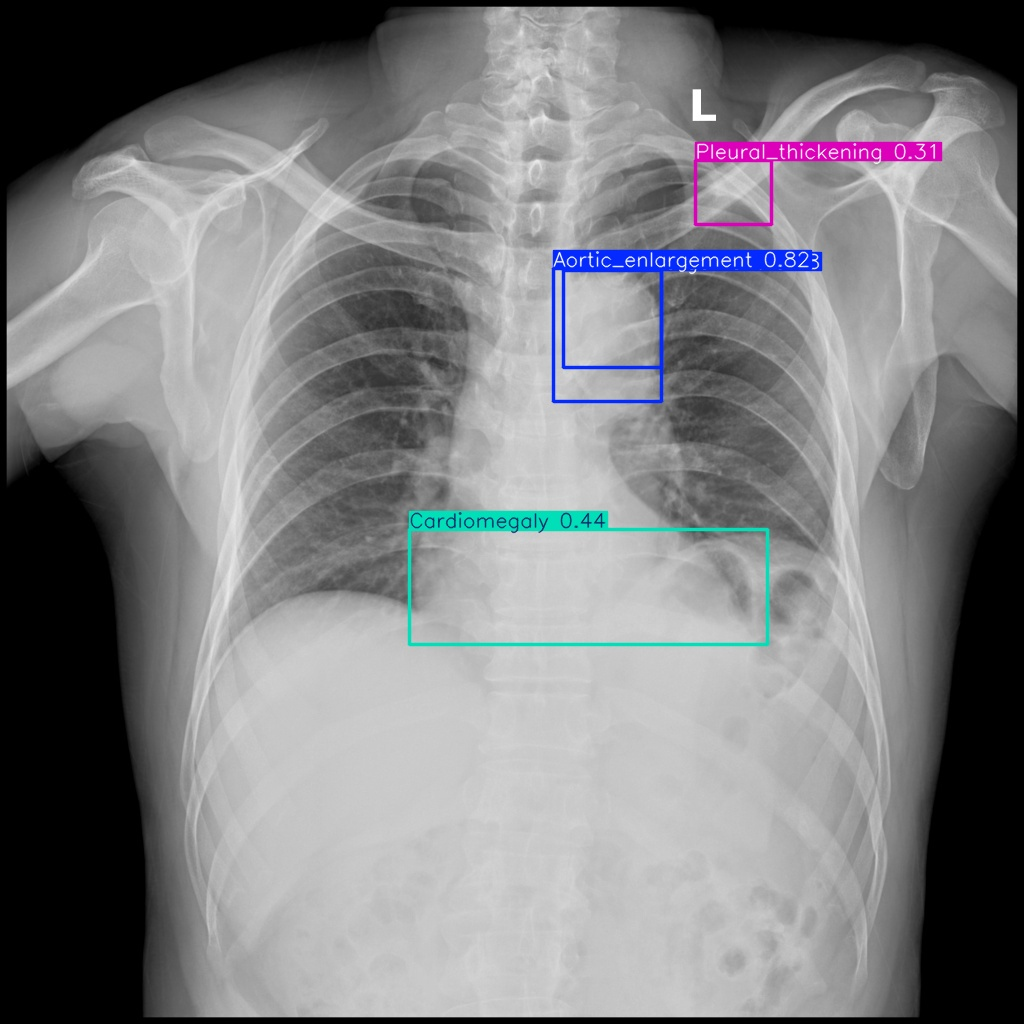



Sample 4:


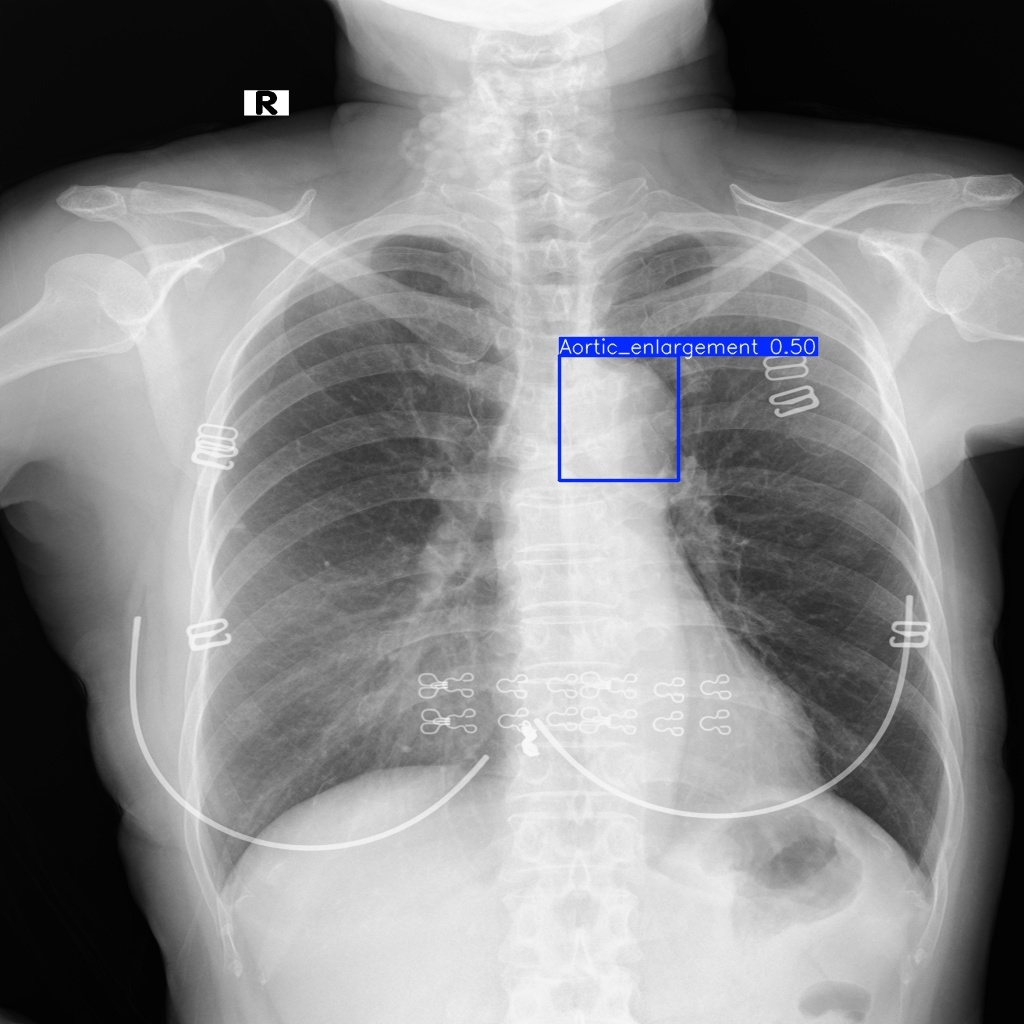



Sample 5:


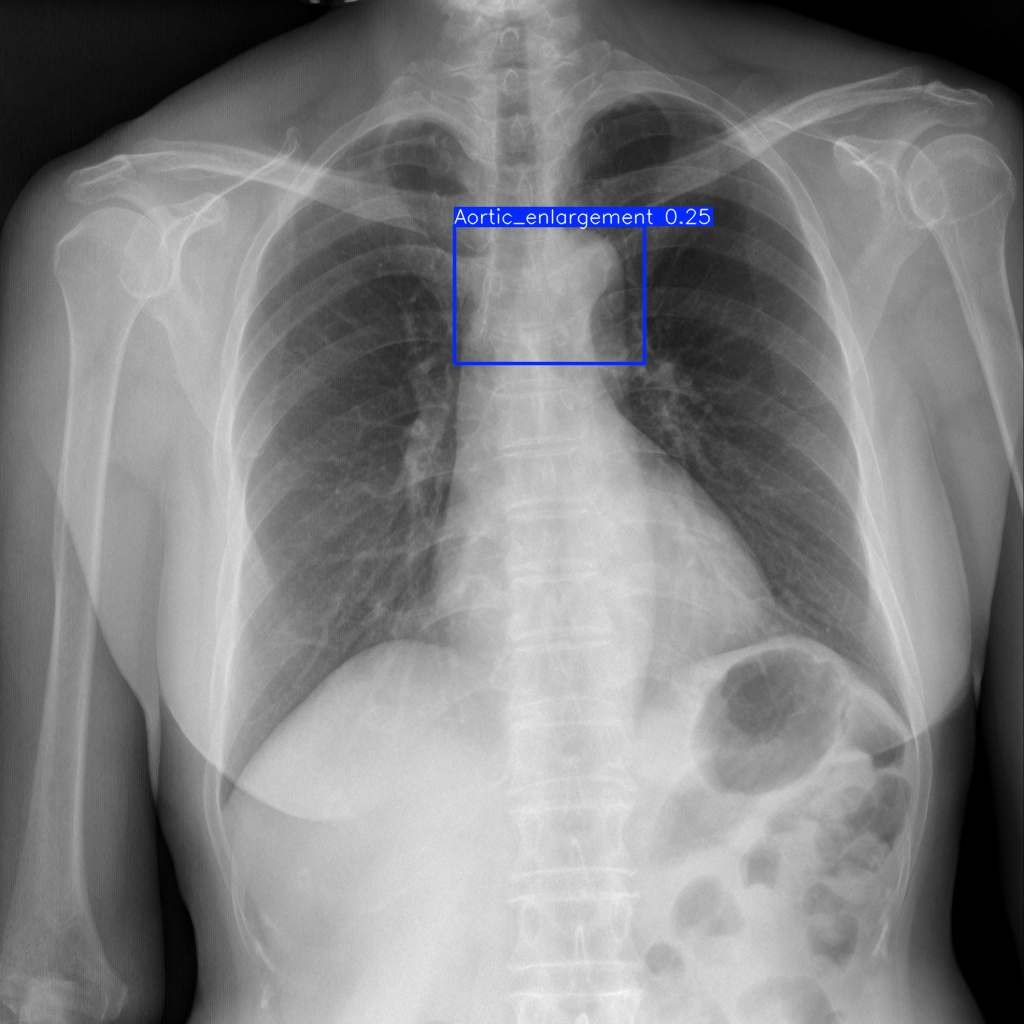

In [29]:
# Display some predictions
from IPython.display import Image, display
import glob
import random

# Get prediction images
pred_images = glob.glob("/content/predictions/cliniscan_val_results/*.jpg")

# Show 5 random predictions
print("🖼️  Sample Predictions with Detections:\n")
random.shuffle(pred_images)

for i, img_path in enumerate(pred_images[:5], 1):
    print(f"Sample {i}:")
    display(Image(filename=img_path, width=700))
    print("\n" + "="*80 + "\n")


In [30]:
# Backup predictions to Drive for your project
import shutil

source = "/content/predictions/cliniscan_val_results"
destination = "/content/drive/MyDrive/CliniScan_Predictions"

print("💾 Backing up predictions to Google Drive...")
shutil.copytree(source, destination, dirs_exist_ok=True)
print("✅ Predictions saved to Drive!")
print(f"📁 Location: {destination}")
print(f"   - {len(os.listdir(destination))} annotated images")
print(f"   - Detection coordinates in labels/ folder")


💾 Backing up predictions to Google Drive...
✅ Predictions saved to Drive!
📁 Location: /content/drive/MyDrive/CliniScan_Predictions
   - 3001 annotated images
   - Detection coordinates in labels/ folder


In [1]:
# ========================================
# EXPORT MODEL TO MULTIPLE FORMATS
# ========================================

from ultralytics import YOLO
import os

# Load your best model
model = YOLO("/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/best.pt")

print("🔄 Exporting model to multiple formats...")
print("⏱️  This will take ~2-3 minutes\n")

# Create export directory in Drive
export_dir = "/content/drive/MyDrive/CliniScan_Exports"
os.makedirs(export_dir, exist_ok=True)

# 1. Export to ONNX (most universal format)
print("1️⃣ Exporting to ONNX format...")
onnx_path = model.export(format="onnx", dynamic=True)
print(f"   ✅ ONNX: {onnx_path}\n")

# 2. Export to TensorFlow SavedModel
print("2️⃣ Exporting to TensorFlow SavedModel...")
tf_path = model.export(format="saved_model")
print(f"   ✅ TensorFlow: {tf_path}\n")

# 3. Export to TorchScript
print("3️⃣ Exporting to TorchScript...")
torchscript_path = model.export(format="torchscript")
print(f"   ✅ TorchScript: {torchscript_path}\n")

# 4. Export to TensorFlow Lite (for mobile)
print("4️⃣ Exporting to TensorFlow Lite (mobile)...")
tflite_path = model.export(format="tflite")
print(f"   ✅ TFLite: {tflite_path}\n")

print("🎉 All exports complete!")
print(f"📁 Exported models available for deployment")

# Copy exports to Drive
import shutil
print("\n💾 Backing up exports to Google Drive...")
for file in os.listdir("."):
    if any(ext in file for ext in ['.onnx', '.torchscript', '_saved_model']):
        try:
            if os.path.isdir(file):
                shutil.copytree(file, os.path.join(export_dir, file), dirs_exist_ok=True)
            else:
                shutil.copy2(file, export_dir)
            print(f"   ✅ Saved: {file}")
        except:
            pass

print(f"\n✅ Exports saved to: {export_dir}")


🔄 Exporting model to multiple formats...
⏱️  This will take ~2-3 minutes

1️⃣ Exporting to ONNX format...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 92 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/CliniScan_Training/yolov8m_vinbig_10242/weights/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 18, 21504) (49.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 241ms
Prepared 6 packages in 1.61s
Installed 6 packages in 241ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnxruntime==1.24.0.dev20251031003
 + onnxslim==0.1.74

requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


O